#### Importamos todas las libreriras que vamos a utilizar

In [412]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe
#import requests

### Acerca de: Inside Airbnb es un proyecto impulsado por una misión que proporciona datos y defensa sobre el impacto de Airbnb en las comunidades residenciales.Trabajamos hacia una visión en la que las comunidades estén empoderadas con datos e información para comprender, decidir y controlar el papel del alquiler de viviendas residenciales a turistas.

Generamos el dataset Airbnb en Buenos Aires

In [413]:
df = pd.read_csv("C:/Users/Gonzalo Rodriguez/OneDrive/Documentos/Especializacion en IA -CEIA/Analisis de datos/TP/listings.csv")

Primera idea de que tiene el data set

In [414]:
df.head()

,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,42610838,"Puerto Madero a 3 cuadras, centro, bello , tea...",224049389,1469188629918707060,Gabriela,NaN,San Nicolas,-34.599976,-58.374195,Entire home/apt,NaN,7.0,0,NaN,NaN,2,244,0,NaN
1,1305876403852901802,Apart estudio en Microcentro,25649070,1465347917068117288,Federico,NaN,San Nicolas,-34.600382,-58.372692,Entire home/apt,NaN,2.0,1,2025-01-18,0.08,1,307,0,NaN
2,1542233033640525302,"Departamento en Buenos Aires, abasto shopping",153014015,1468500000533080859,Marco,NaN,Balvanera,-34.603295,-58.409527,Entire home/apt,NaN,7.0,0,NaN,NaN,1,326,0,NaN
3,1004530078359434134,Departamento en Recoleta,1409800,1462517876404348407,Marian,NaN,Balvanera,-34.599230,-58.407060,Entire home/apt,NaN,1.0,22,2025-12-07,0.80,39,365,3,NaN
4,800145927121871422,Coqueto para 4 personas,467965425,1470109782901816721,Maria Del Carmen,NaN,Almagro,-34.599767,-58.426499,Entire home/apt,NaN,1.0,0,NaN,NaN,2,365,0,NaN


#### Hacemos un shape y vemos que el data set tiene 22877 observaciones distribuida en 15 variables

In [415]:
df.shape

(27348, 19)

Informacion de las variables

In [416]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27348 entries, 0 to 27347
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              27348 non-null  int64  
 1   name                            27348 non-null  str    
 2   host_id                         27348 non-null  int64  
 3   host_profile_id                 27348 non-null  int64  
 4   host_name                       27348 non-null  str    
 5   neighbourhood_group             0 non-null      float64
 6   neighbourhood                   27348 non-null  str    
 7   latitude                        27348 non-null  float64
 8   longitude                       27348 non-null  float64
 9   room_type                       27348 non-null  str    
 10  price                           0 non-null      float64
 11  minimum_nights                  27242 non-null  float64
 12  number_of_reviews               27348 non-n

Variables numericas

In [417]:
df.describe()

,id,host_id,host_profile_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,2.734800e+04,2.734800e+04,2.734800e+04,0.0,27348.000000,27348.000000,0.0,27242.000000,27348.000000,24045.000000,27348.000000,27348.000000,27348.000000
mean,8.556780e+17,2.372763e+08,1.469908e+18,NaN,-34.592076,-58.416340,NaN,4.748770,38.127176,1.464834,12.394398,239.999963,12.231827
std,5.477969e+17,2.233505e+08,1.840941e+16,NaN,0.017927,0.029938,NaN,16.434273,56.082583,1.559983,27.895493,113.614547,17.429681
min,1.150800e+04,1.342600e+04,1.462507e+18,NaN,-34.690056,-58.530890,NaN,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000
25%,5.626035e+17,3.427341e+07,1.462899e+18,NaN,-34.603202,-58.435973,NaN,1.000000,4.000000,0.390000,1.000000,151.000000,1.000000
50%,9.886724e+17,1.587017e+08,1.466922e+18,NaN,-34.591370,-58.418325,NaN,2.000000,17.000000,1.000000,2.000000,269.000000,5.000000
75%,1.293344e+18,4.600936e+08,1.469954e+18,NaN,-34.581471,-58.391140,NaN,3.000000,51.000000,2.030000,9.000000,344.000000,17.000000
max,1.605545e+18,7.420151e+08,1.605075e+18,NaN,-34.535630,-58.355403,NaN,730.000000,1044.000000,28.690000,188.000000,365.000000,329.000000


Las variables id, host_id y hot_profile_id son variables identificatorias de publicaciones, identificacion de anfitrion, perfil del anfitrion.  Luego price y neighbourhood_group esta vacia. Tanto latitud y longitud describen la ubicacione de cada publicacion. Las variables minimun_nights, number_of_reviews, reviews_por_month, calculated_host_lisitng_count y number_of_reviws_ltm son variables que tienen mucha asimetria con un cola muy larga hacia la derecha.La variable availability_365 tiene una dispersion en todo el rango de dias.

Variables Numericas: Tenemos 13 variables numericas. 

| Variable | Traducción | Descripción | Tipo | Observación |
|---|---|---|---|---|
| `id` | Identificador del alojamiento | ID único de cada publicación | Discreta | Identificador, sin sentido aritmético |
| `host_id` | Identificador del anfitrión | ID único del anfitrión | Discreta | Identificador, sin sentido aritmético |
| `host_profile_id` | Identificador de perfil del anfitrión | ID del perfil público del anfitrión | Discreta | Identificador, sin sentido aritmético |
| `neighbourhood_group` | Grupo de barrio | Zona o distrito donde se ubica el alojamiento | Discreta | Columna vacía en el dataset |
| `latitude` | Latitud | Coordenada geográfica norte-sur del alojamiento | Continua | Coordenada geoespacial |
| `longitude` | Longitud | Coordenada geográfica este-oeste del alojamiento | Continua | Coordenada geoespacial |
| `price` | Precio por noche | Precio en moneda local por noche | Continua | Columna vacía en el dataset |
| `minimum_nights` | Noches mínimas | Cantidad mínima de noches para reservar | Discreta | Toma valores enteros positivos |
| `number_of_reviews` | Número de reseñas | Total acumulado de reseñas del alojamiento | Discreta | Toma valores enteros positivos |
| `reviews_per_month` | Reseñas por mes | Promedio mensual de reseñas recibidas | Continua | Puede tomar cualquier valor decimal |
| `calculated_host_listings_count` | Publicaciones del anfitrión | Número de alojamientos publicados por el anfitrión | Discreta | Toma valores enteros positivos |
| `availability_365` | Disponibilidad anual | Días disponibles en los próximos 365 días | Discreta | Valores enteros entre 0 y 365 |
| `number_of_reviews_ltm` | Reseñas últimos 12 meses | Cantidad de reseñas recibidas en el último año | Discreta | Toma valores enteros positivos |

Ahora veamos las variables categoricas

In [418]:
df.describe(include=['str'])

,name,host_name,neighbourhood,room_type,last_review,license
count,27348,27348,27348,27348,24045,461
unique,25866,3841,48,4,1537,424
top,Departamento en Buenos Aires,Federico,Palermo,Entire home/apt,2026-01-11,IF-2025-23263934-GCABA-DGDTU
freq,69,465,8963,24890,600,8


Las variables categoricas son name que es el nombre del alojamiento y hot_name nombre del anfitrion,vemos que ambas variables tienen muchisima cantidad de variables. El caso de neighbourhood son 48 barrios distintos y room type son solo 4 variables. En el caso de license hay solo 461 datos de los 27348 registgros. En caso de last_review, vamos a cambiar a variable numerica porque es la fecha de la ultima resena recibida

| Variable | Traducción | Descripción | Tipo | Observación |
|---|---|---|---|---|
| `name` | Nombre del alojamiento | Título de la publicación en Airbnb | Nominal | Texto libre, alta cardinalidad |
| `host_name` | Nombre del anfitrión | Nombre público del anfitrión | Nominal | Texto libre, alta cardinalidad |
| `neighbourhood` | Barrio | Barrio donde se ubica el alojamiento | Nominal | Cantidad acotada de valores únicos |
| `room_type` | Tipo de habitación | Tipo de alojamiento ofrecido (casa completa, habitación privada, etc.) | Nominal | Pocos valores únicos |
| `last_review` | Última reseña | Fecha de la última reseña recibida | — | Variable temporal, no categórica pura |
| `license` | Licencia | Número de licencia o habilitación del alojamiento | Nominal | Columna vacía en el dataset |

Vamos a modificar la variable 'last_review' a variable numerica, ya que es una variable que se utiliza para medir tiempo transcurrido

In [419]:
df['last_review'] = pd.to_datetime(df['last_review'])

In [420]:
df.describe()

,id,host_id,host_profile_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,2.734800e+04,2.734800e+04,2.734800e+04,0.0,27348.000000,27348.000000,0.0,27242.000000,27348.000000,24045,24045.000000,27348.000000,27348.000000,27348.000000
mean,8.556780e+17,2.372763e+08,1.469908e+18,NaN,-34.592076,-58.416340,NaN,4.748770,38.127176,2025-08-01 16:06:02.919526,1.464834,12.394398,239.999963,12.231827
min,1.150800e+04,1.342600e+04,1.462507e+18,NaN,-34.690056,-58.530890,NaN,1.000000,0.000000,2013-01-06 00:00:00,0.010000,1.000000,0.000000,0.000000
25%,5.626035e+17,3.427341e+07,1.462899e+18,NaN,-34.603202,-58.435973,NaN,1.000000,4.000000,2025-10-09 00:00:00,0.390000,1.000000,151.000000,1.000000
50%,9.886724e+17,1.587017e+08,1.466922e+18,NaN,-34.591370,-58.418325,NaN,2.000000,17.000000,2025-12-20 00:00:00,1.000000,2.000000,269.000000,5.000000
75%,1.293344e+18,4.600936e+08,1.469954e+18,NaN,-34.581471,-58.391140,NaN,3.000000,51.000000,2026-01-08 00:00:00,2.030000,9.000000,344.000000,17.000000
max,1.605545e+18,7.420151e+08,1.605075e+18,NaN,-34.535630,-58.355403,NaN,730.000000,1044.000000,2026-01-25 00:00:00,28.690000,188.000000,365.000000,329.000000
std,5.477969e+17,2.233505e+08,1.840941e+16,NaN,0.017927,0.029938,NaN,16.434273,56.082583,NaN,1.559983,27.895493,113.614547,17.429681


Vemos como 'last_review' ya aparece en la descripcion de variables numericas. Vemos que esta variable last_review tiene fecha (año, mes, dia) y ademas hora. minuto y segundo

Porcentaje de valores nulos

In [421]:
df.isna().mean() * 100

id                                  0.000000
name                                0.000000
host_id                             0.000000
host_profile_id                     0.000000
host_name                           0.000000
neighbourhood_group               100.000000
neighbourhood                       0.000000
latitude                            0.000000
longitude                           0.000000
room_type                           0.000000
price                             100.000000
minimum_nights                      0.387597
number_of_reviews                   0.000000
last_review                        12.077666
reviews_per_month                  12.077666
calculated_host_listings_count      0.000000
availability_365                    0.000000
number_of_reviews_ltm               0.000000
license                            98.314319
dtype: float64

Vemos el porcentaje de nulos en cada una de las variables. Se observan en principio que las variables **'price'** y **'neighbourhood_group'** ya que estan completamente vacias. Y habra que revisar la variable **'license'** que esta con el 98% de valores faltntes, casi vacia de datos.

### Vamos a realizar graficos para observar comportamientos de las variables

Realicemos un pair plot de todas las variables numericas para ver su distribucion y realacion

In [422]:
cols = df.select_dtypes(include=['number']).columns.tolist()
print(cols)

['id', 'host_id', 'host_profile_id', 'neighbourhood_group', 'latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm']


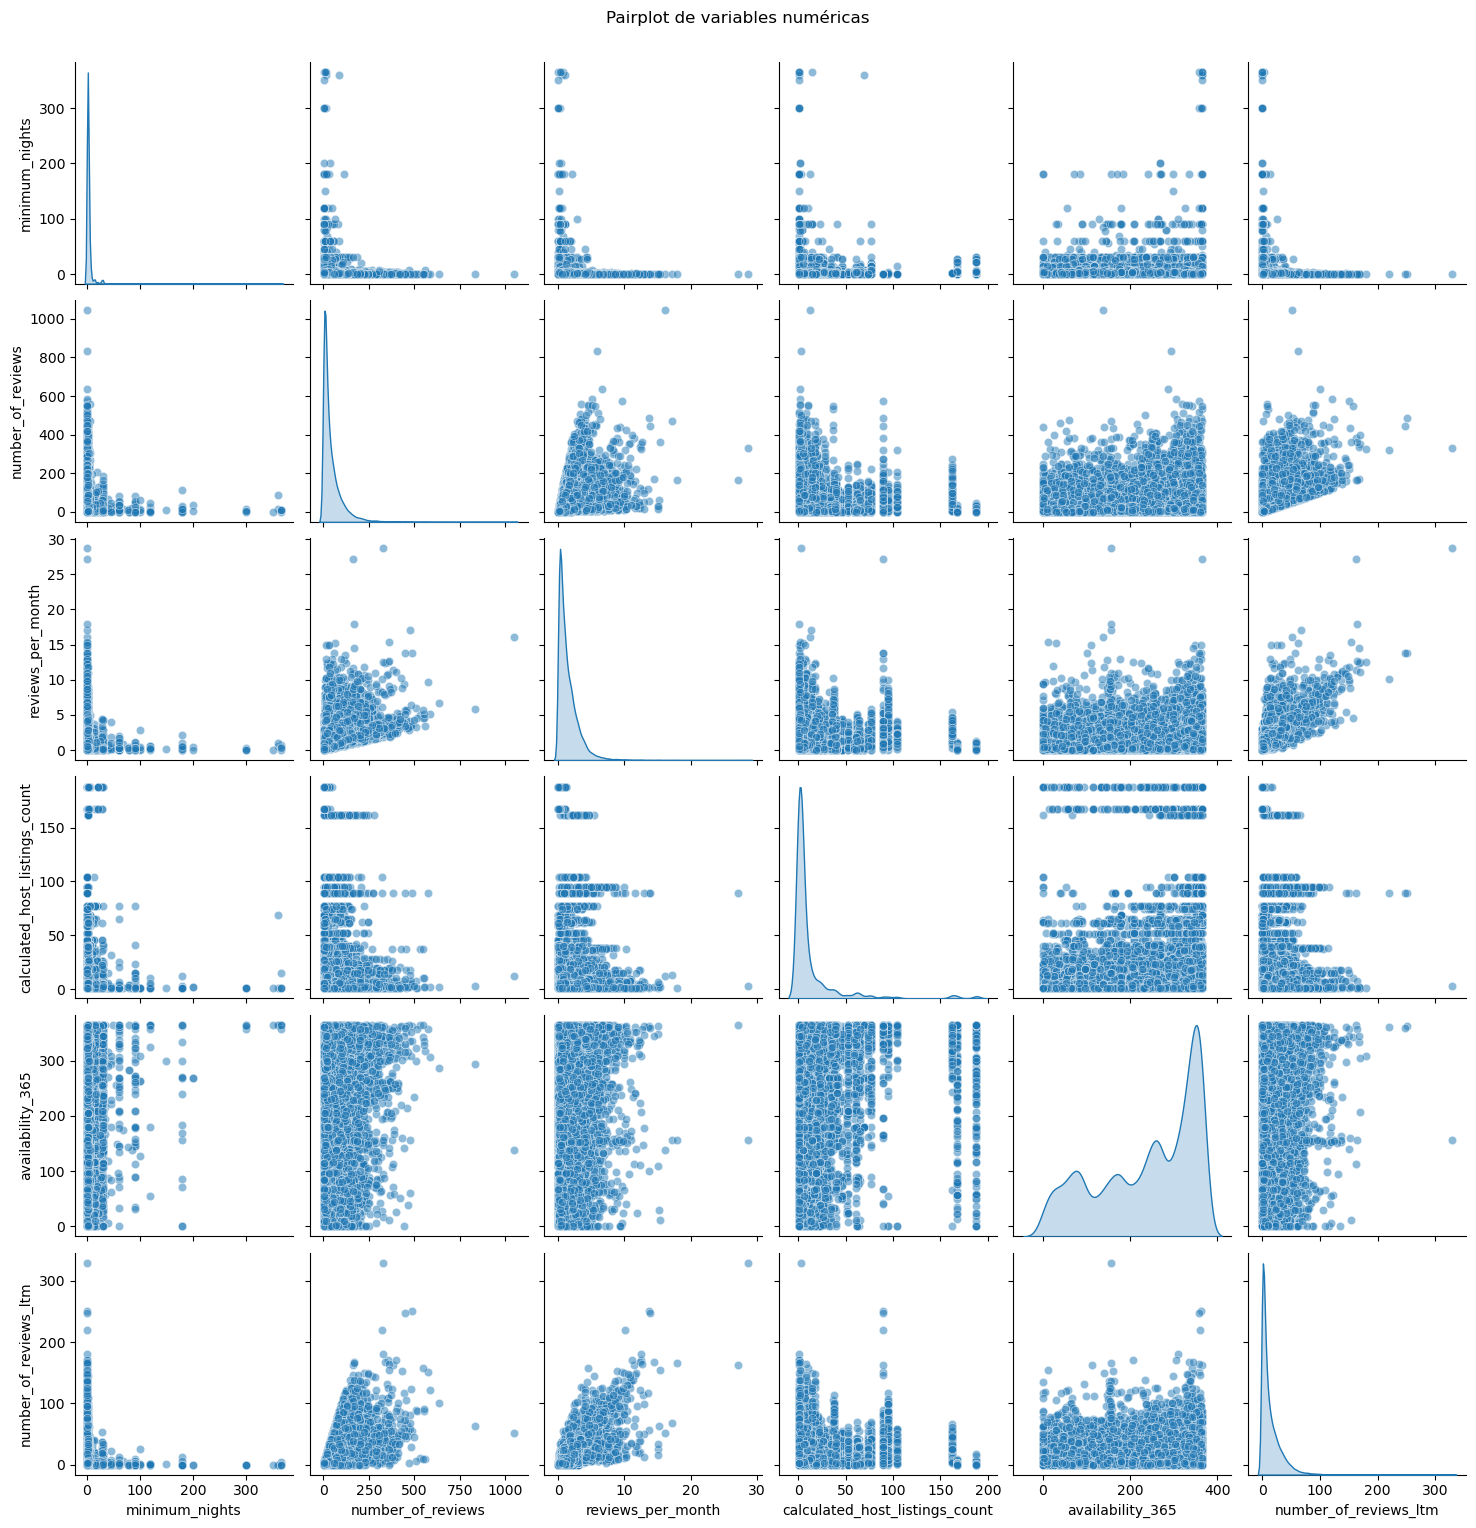

In [425]:
cols = ['minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm']

sns.pairplot(df[cols].dropna(), diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot de variables numéricas', y=1.02)
plt.show()

En las graficas de distribucion se observa 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count',  'number_of_reviews_ltm' todas tienen un asimetria muy grande con un cola pronunciada hacia la derecha y en el caso de 'last_review_num' es al reves tiene un asimetria muy grande hacia la izquierda

Slice del dataframe para poder hacer un grafico de cantidad de Airbnb por barrio (mostrando solo los mas populares)

In [426]:
barrios_id_df = df[["neighbourhood", "id"]]
barrios_id_df

,neighbourhood,id
0,San Nicolas,42610838
1,San Nicolas,1305876403852901802
2,Balvanera,1542233033640525302
3,Balvanera,1004530078359434134
4,Almagro,800145927121871422
...,...,...
27343,Villa Crespo,1587119060096878911
27344,Palermo,37623532
27345,Villa Crespo,1074846345919500333
27346,Villa Crespo,1028342669639305203


Agrupar por barrio y agregar la variable de cantidad de veces que el barrio es observado

In [427]:
barrios_id_df =  barrios_id_df.groupby(['neighbourhood'])["id"].count().reset_index(name='Count').sort_values(['Count'], ascending=False)
barrios_id_df =  barrios_id_df[barrios_id_df["Count"] > 1000]
barrios_id_df

,neighbourhood,Count
20,Palermo,8963
27,Recoleta,3828
31,San Nicolas,2156
4,Belgrano,1318
28,Retiro,1310
16,Monserrat,1256
2,Balvanera,1051
1,Almagro,1011


Otro slice para quedarnos con los barrios con mas de 1000 Airbnb

In [428]:
top_barrios_df = df[df["neighbourhood"].isin(["Palermo", "Recoleta", "San Nicolas", "Belgrano", "Retiro", "Monserrat", "Balvanera", "Almagro"])]

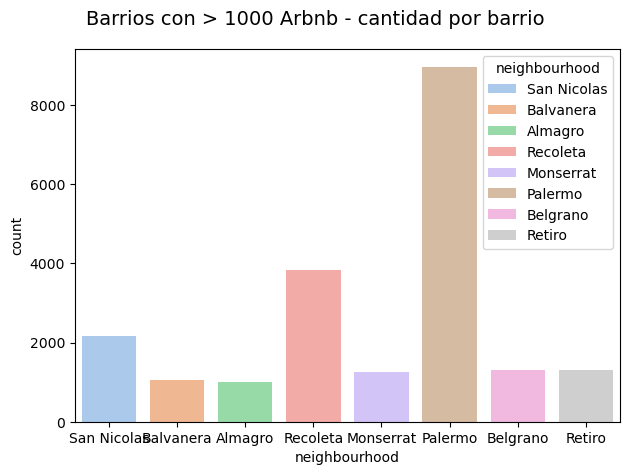

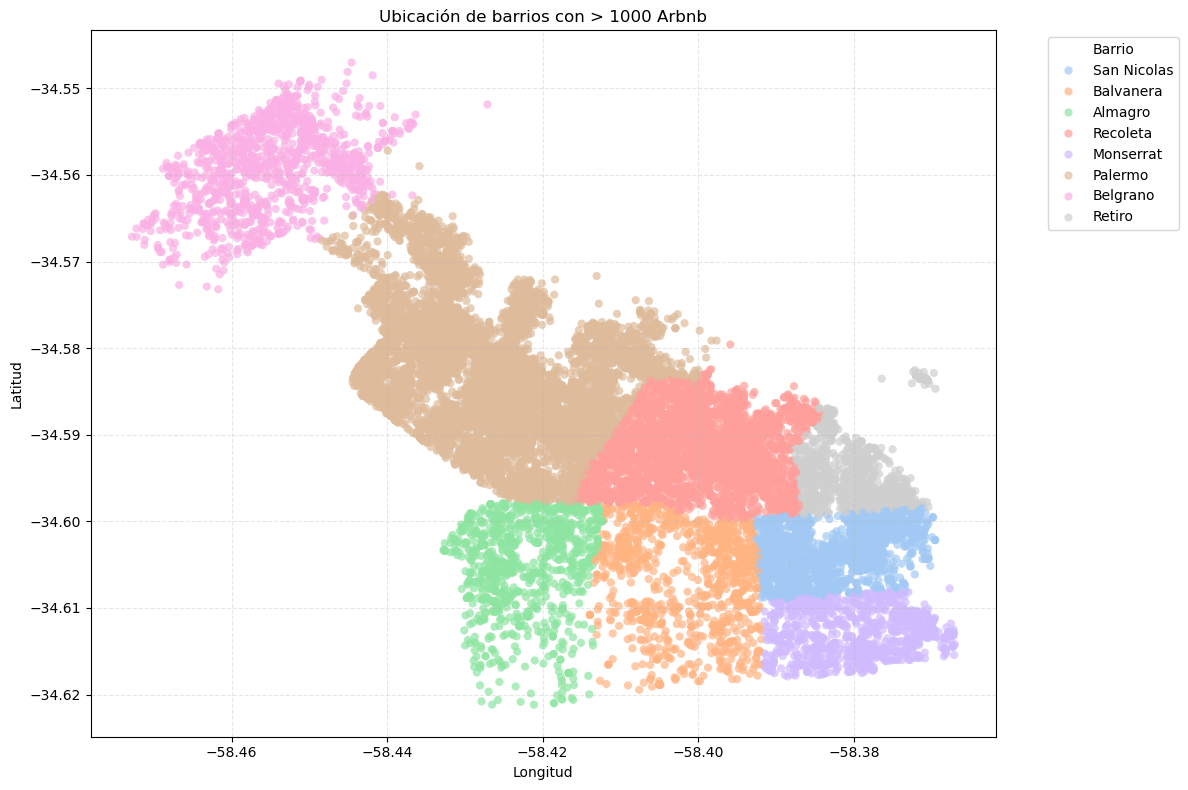

In [429]:
sns.countplot(x="neighbourhood", data=top_barrios_df, hue="neighbourhood", palette='pastel', legend='brief')

plt.suptitle('Barrios con > 1000 Arbnb - cantidad por barrio', fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=top_barrios_df, x='longitude', y='latitude', hue='neighbourhood', palette='pastel', alpha=0.7, s=35, edgecolor='none')
plt.title('Ubicación de barrios con > 1000 Arbnb')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Barrio')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

Grafico de disponibilidad

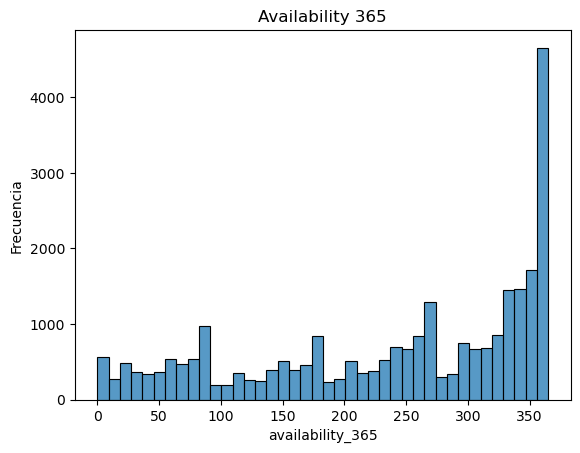

In [430]:
sns.histplot(df["availability_365"].dropna(), bins=40)
plt.title("Availability 365")
plt.xlabel("availability_365")
plt.ylabel("Frecuencia")
plt.show()

Cantidad de reviews vs disponibilidad

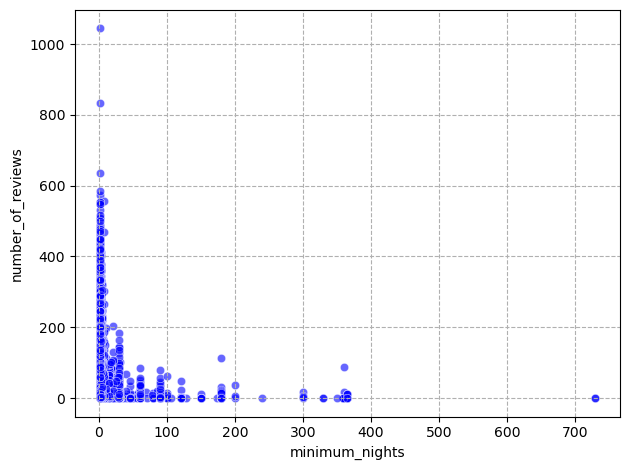

In [431]:

sns.scatterplot(data=df, x='minimum_nights', y='number_of_reviews', color='b',alpha=0.6)
	
plt.grid(ls='--')
plt.title('')
plt.tight_layout()
plt.show()

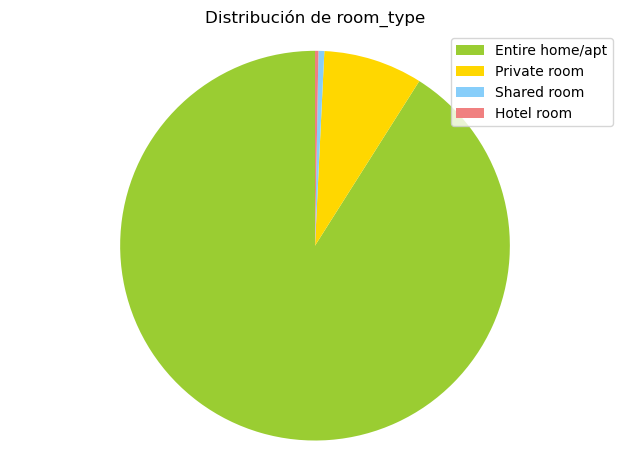

In [432]:
#plot_pie(Airbnb_df, "room_type")
labels = df["room_type"].value_counts().index
colors = ['yellowgreen', 'gold', 'lightskyblue', 'lightcoral']
patches, texts = plt.pie(df["room_type"].value_counts(), colors=colors, startangle=90)
plt.title(f'Distribución de room_type')
plt.legend(patches, labels, loc="best")
# Set aspect ratio to be equal so that pie is drawn as a circle.
plt.axis('equal')
plt.tight_layout()
plt.show()

Observamos en este grafico de torta que casi la mayoria de la oferta son home/aprt o en mucha menor cantidad habitaciones privada, y muy infima la oferta de habitaciones de hotel o habitacions compartidas

Realizamos un boxplot de cada una de las variables numericas. En la mayoria de los casos, si se hace con el total de los datos queda totalmente dificil de interpretar, solamente eliminando el 1% y aqueda un grafico mucho mas aceptable para interpretarlo

In [433]:
df.describe()

,id,host_id,host_profile_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,2.734800e+04,2.734800e+04,2.734800e+04,0.0,27348.000000,27348.000000,0.0,27242.000000,27348.000000,24045,24045.000000,27348.000000,27348.000000,27348.000000
mean,8.556780e+17,2.372763e+08,1.469908e+18,NaN,-34.592076,-58.416340,NaN,4.748770,38.127176,2025-08-01 16:06:02.919526,1.464834,12.394398,239.999963,12.231827
min,1.150800e+04,1.342600e+04,1.462507e+18,NaN,-34.690056,-58.530890,NaN,1.000000,0.000000,2013-01-06 00:00:00,0.010000,1.000000,0.000000,0.000000
25%,5.626035e+17,3.427341e+07,1.462899e+18,NaN,-34.603202,-58.435973,NaN,1.000000,4.000000,2025-10-09 00:00:00,0.390000,1.000000,151.000000,1.000000
50%,9.886724e+17,1.587017e+08,1.466922e+18,NaN,-34.591370,-58.418325,NaN,2.000000,17.000000,2025-12-20 00:00:00,1.000000,2.000000,269.000000,5.000000
75%,1.293344e+18,4.600936e+08,1.469954e+18,NaN,-34.581471,-58.391140,NaN,3.000000,51.000000,2026-01-08 00:00:00,2.030000,9.000000,344.000000,17.000000
max,1.605545e+18,7.420151e+08,1.605075e+18,NaN,-34.535630,-58.355403,NaN,730.000000,1044.000000,2026-01-25 00:00:00,28.690000,188.000000,365.000000,329.000000
std,5.477969e+17,2.233505e+08,1.840941e+16,NaN,0.017927,0.029938,NaN,16.434273,56.082583,NaN,1.559983,27.895493,113.614547,17.429681


Vemos el top 10 de usuario que mayor cantidad de publicaciones tienen

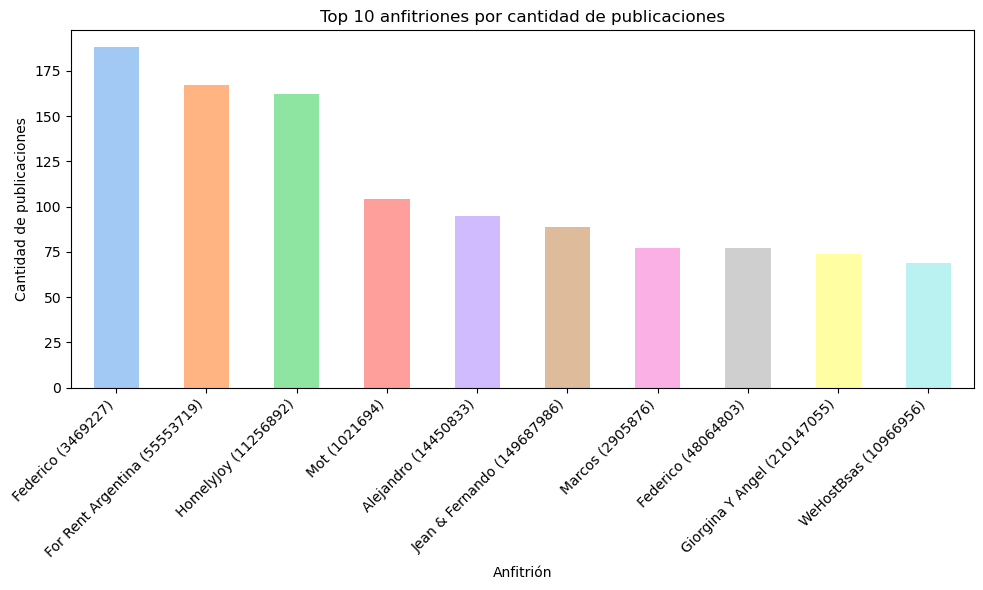

In [434]:
usuario_max = df.groupby(['host_id', 'host_name'])['id'].count().sort_values(ascending=False).head(10)
usuario_max.index = [f"{name} ({uid})" for uid, name in usuario_max.index]

plt.figure(figsize=(10,6))
usuario_max.plot(kind='bar', color=sns.color_palette('pastel', len(usuario_max)))
plt.title('Top 10 anfitriones por cantidad de publicaciones')
plt.xlabel('Anfitrión')
plt.ylabel('Cantidad de publicaciones')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Vemos los barrios con mayor cantidad de reviews el ultimo ano

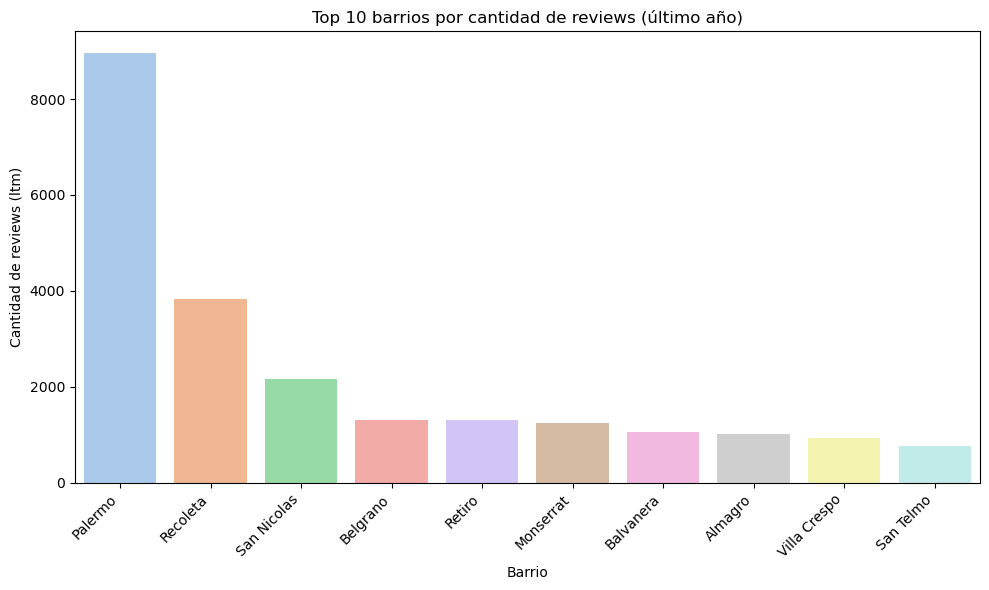

In [435]:
barrios_max = df.groupby("neighbourhood")["number_of_reviews_ltm"].count().sort_values(ascending=False).head(10)
top = barrios_max.reset_index(name='count')

plt.figure(figsize=(10,6))
sns.barplot(data=top, x='neighbourhood', y='count', palette='pastel', 
            hue='neighbourhood', legend=False, order=top['neighbourhood'])
plt.title('Top 10 barrios por cantidad de reviews (último año)')
plt.xlabel('Barrio')
plt.ylabel('Cantidad de reviews (ltm)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Vamos a recortar los valores extremos de las variables que tienen mucha cola para observar la distribución de la mayoría de los valores.

=== TABLA DE PERCENTILES ===

--- minimum_nights ---
count    27242.000000
mean         4.748770
std         16.434273
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
90%          7.000000
95%         15.000000
99%         40.000000
max        730.000000
Name: minimum_nights, dtype: float64

--- number_of_reviews ---
count    27348.000000
mean        38.127176
std         56.082583
min          0.000000
25%          4.000000
50%         17.000000
75%         51.000000
90%        102.000000
95%        145.000000
99%        270.530000
max       1044.000000
Name: number_of_reviews, dtype: float64

--- reviews_per_month ---
count    24045.000000
mean         1.464834
std          1.559983
min          0.010000
25%          0.390000
50%          1.000000
75%          2.030000
90%          3.340000
95%          4.290000
99%          7.210000
max         28.690000
Name: reviews_per_month, dtype: float64

--- calculated_host_listings_count ---
count    2

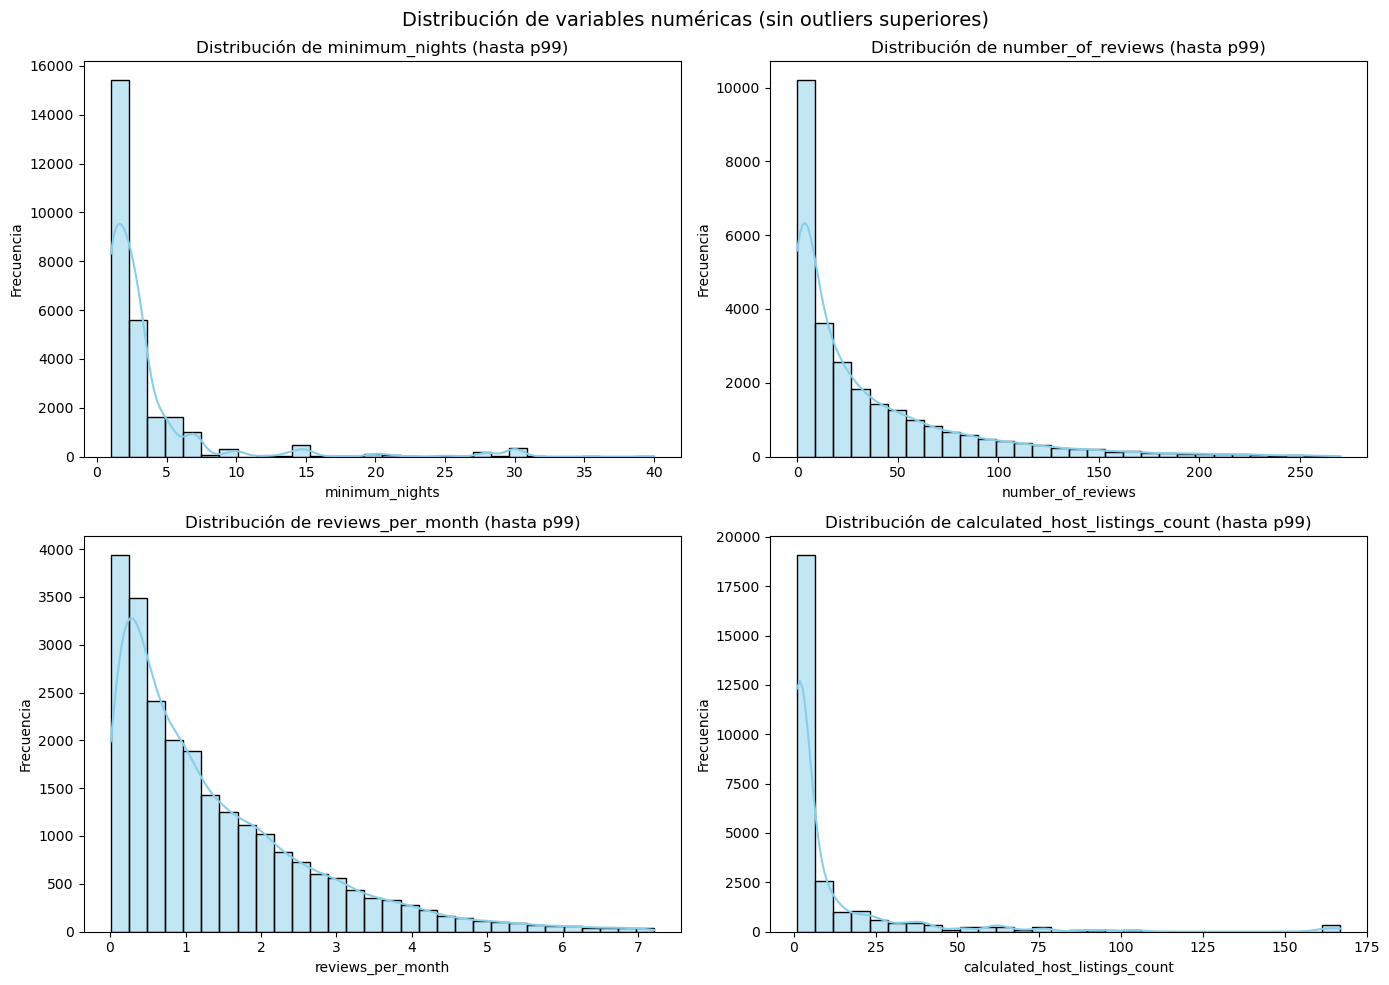

In [436]:
variables = ['minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count']

# Tabla de percentiles
print("=== TABLA DE PERCENTILES ===\n")
for var in variables:
    print(f"--- {var} ---")
    print(df[var].describe(percentiles=[.25, .50, .75, .90, .95, .99]))
    print()

# Histogramas recortados por p99
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(variables):
    p99 = df[var].quantile(0.99)
    datos = df[df[var] <= p99][var].dropna()
    
    sns.histplot(datos, bins=30, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución de {var} (hasta p99)')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de variables numéricas (sin outliers superiores)', fontsize=14)
plt.tight_layout()
plt.show()

Veamos la distribucion de publicaciones por barrio.

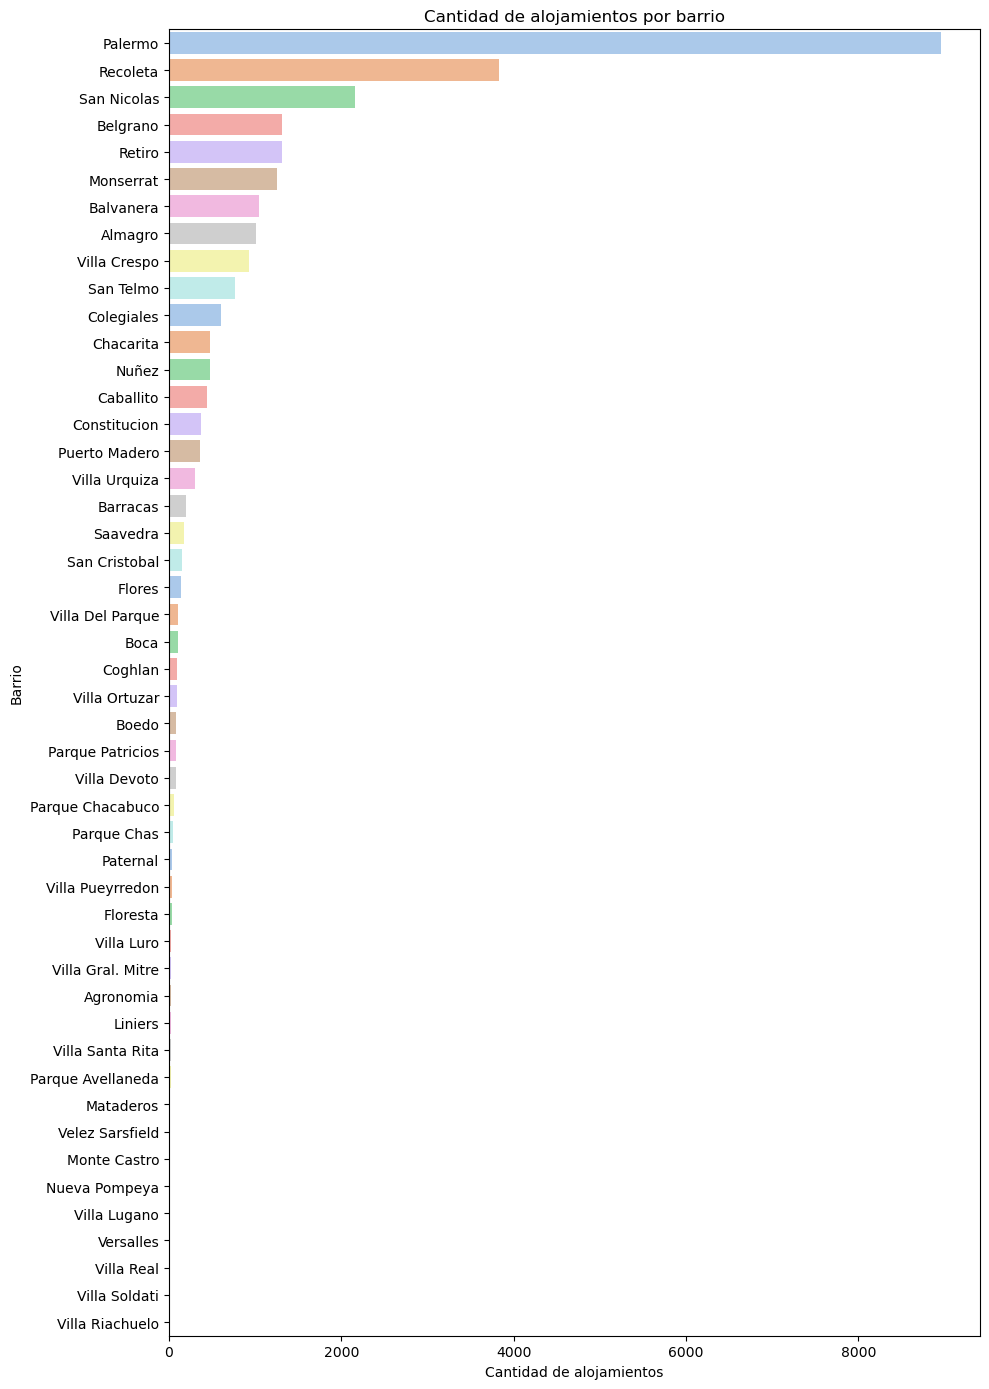

In [437]:
plt.figure(figsize=(10, 14))

neighbourhood_counts = df['neighbourhood'].value_counts()

sns.barplot(x=neighbourhood_counts.values, 
            y=neighbourhood_counts.index,
            hue=neighbourhood_counts.index,
            legend=False,
            palette='pastel')

plt.title('Cantidad de alojamientos por barrio')
plt.xlabel('Cantidad de alojamientos')
plt.ylabel('Barrio')
plt.tight_layout()
plt.show()

Disponibilidad dependiendo del tipo de alojamiento

<Axes: xlabel='room_type', ylabel='availability_365'>

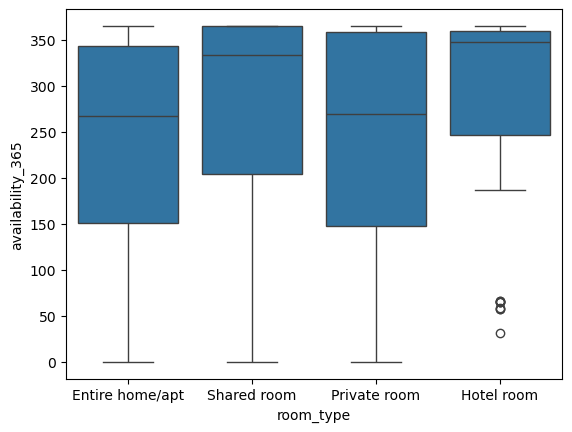

In [438]:
sns.boxplot(data=df, x='room_type', y='availability_365')

Verificamos que barrios tienen mas disponibilidad

<Axes: xlabel='availability_365', ylabel='neighbourhood'>

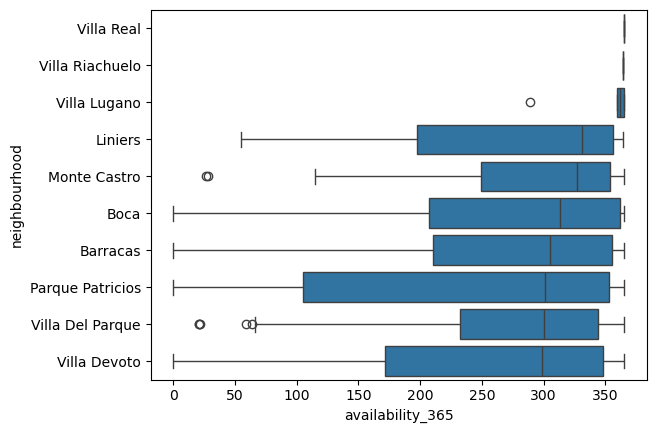

In [439]:
orden = df.groupby('neighbourhood')['availability_365'].median().sort_values(ascending=False).head(10).index
sns.boxplot(data=df[df['neighbourhood'].isin(orden)], x='availability_365', y='neighbourhood', order=orden)

Ralizamos una matriz de correlacion entre las variables numericas

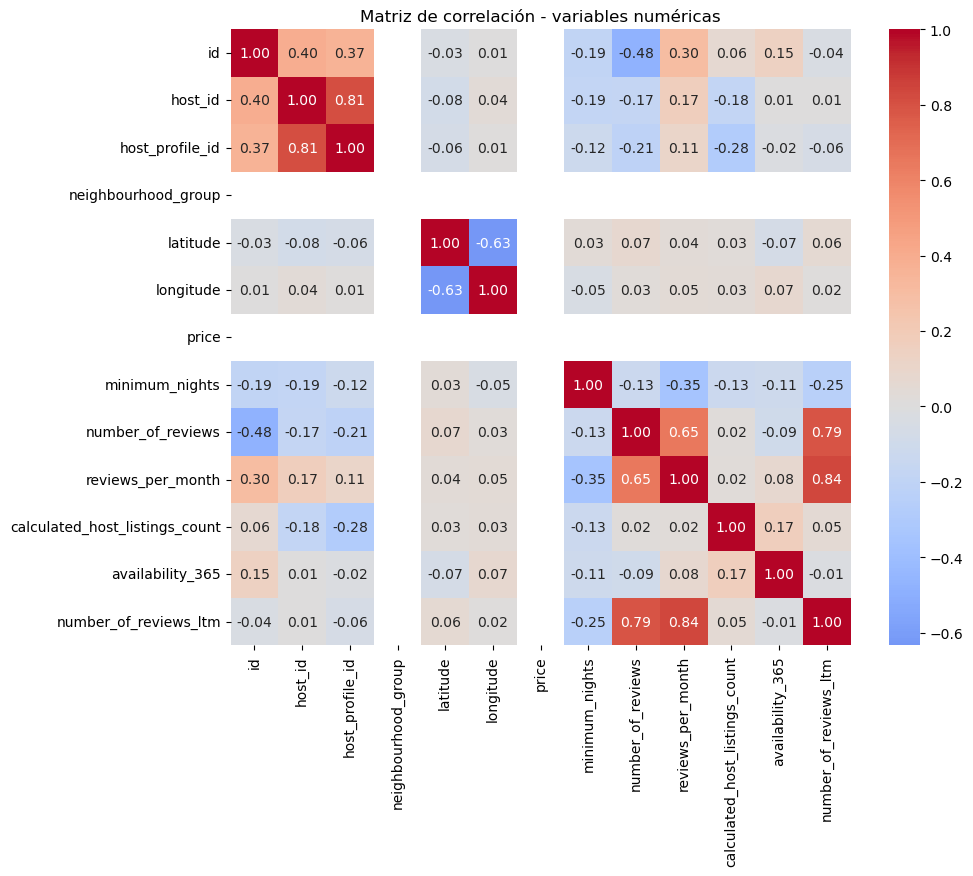

In [440]:
numerical_cols = df.select_dtypes(include=['number']).columns
corr = df[numerical_cols].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación - variables numéricas")
plt.show()

Se observa la matriz de correlacion de sperman entre las variables numericas, hay alguna correlaciones entre los distintos numeros de reviews y alguna correlacion entre los distntos id's

Vamos a hacer una correlacion entre variables categoricas y numericas para ver si hay alguna correlacion

In [441]:
def eta_cuadrado(categorica, numerica):
    df_clean = df[[categorica, numerica]].dropna()  # elimina nulos de ambas columnas
    
    grupos = df_clean.groupby(categorica)[numerica].apply(list)
    grand_mean = df_clean[numerica].mean()
    
    ss_between = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in grupos)
    ss_total = sum((x - grand_mean)**2 for x in df_clean[numerica])
    
    return ss_between / ss_total
# Variables a comparar
comparaciones = [
    ('room_type', 'number_of_reviews'),
    ('room_type', 'availability_365'),
    ('room_type', 'minimum_nights'),
    ('neighbourhood', 'availability_365'),
    ('neighbourhood', 'number_of_reviews'),
]

print("=== ETA CUADRADO ===\n")
print(f"{'Categórica':<20} {'Numérica':<30} {'Eta²':<10} {'Interpretación'}")
print("-" * 75)

for cat, num in comparaciones:
    eta2 = eta_cuadrado(cat, num)
    
    if eta2 < 0.01:
        interpretacion = "sin efecto"
    elif eta2 < 0.06:
        interpretacion = "efecto pequeño"
    elif eta2 < 0.14:
        interpretacion = "efecto moderado"
    else:
        interpretacion = "efecto grande"
    
    print(f"{cat:<20} {num:<30} {eta2:.4f}     {interpretacion}")

=== ETA CUADRADO ===

Categórica           Numérica                       Eta²       Interpretación
---------------------------------------------------------------------------
room_type            number_of_reviews              0.0095     sin efecto
room_type            availability_365               0.0014     sin efecto
room_type            minimum_nights                 0.0003     sin efecto
neighbourhood        availability_365               0.0076     sin efecto
neighbourhood        number_of_reviews              0.0301     efecto pequeño


## Tratamiento de datos faltantes y outliers

Antes de hacer el split del data set vamos a eliminar las columnas con datos faltantes **price** y **neighbourhood_group**

In [442]:
df = df.drop(columns=['price', 'neighbourhood_group']).copy()

In [443]:
df.shape

(27348, 17)

In [444]:
df.shape

(27348, 17)

Como habiamos visto antes veamos el pocentaje de nulos en cada una de las variables que quedaron:

In [445]:
print((df.isnull().sum() / len(df) * 100).sort_values(ascending=False).round(2))

license                           98.31
last_review                       12.08
reviews_per_month                 12.08
minimum_nights                     0.39
id                                 0.00
name                               0.00
host_id                            0.00
host_profile_id                    0.00
host_name                          0.00
room_type                          0.00
longitude                          0.00
latitude                           0.00
neighbourhood                      0.00
number_of_reviews                  0.00
calculated_host_listings_count     0.00
availability_365                   0.00
number_of_reviews_ltm              0.00
dtype: float64


Se observa que la variable **license** tiene un 98.31% de valores faltantes, 
por lo que prácticamente está vacía y la eliminaremos. Las variables 
**reviews_per_month** y **last_review**(12.08%) y **minimum_nights** (0.39%) tienen valores 
faltantes que analizaremos para decidir cómo imputarlos.

Entonces eliminamos la columna **license**

In [446]:
df = df.drop(columns=['license']).copy()

In [447]:
df.shape

(27348, 16)

Vamos a pasar la variable last_review, a las columnas de ano, mes y dia por separado

In [448]:
df['last_review_anio'] = df['last_review'].dt.year
df['last_review_mes'] = df['last_review'].dt.month
df['last_review_dia'] = df['last_review'].dt.day
df = df.drop(columns=['last_review']).copy()

In [449]:
df.shape

(27348, 18)

### Vamos a definir que tipo de traget vamos a seleccionar y para que tipo de problema seria. Vamos a seleccionar como target la variable **availability_365** por lo que vamos a dejar listo para resolver un problema de regresion para tratar de predecir el valor de disponibilidad de un alojamiento en realcion al resto de las variables

In [450]:
y = df['availability_365']
X = df.drop(columns=['availability_365']).copy()

Verificamos filas y columnas de X e y

In [451]:
X.shape, y.shape

((27348, 17), (27348,))

ahora vamos a realizar el train test split asi podemos realizar todas las traformaciones en el test y luego la aplicamos en el test

In [452]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (19143, 17)
X_test:  (8205, 17)
y_train: (19143,)
y_test:  (8205,)


Ahora vamos a trabajar en la imputacion de ausentes.

In [453]:
print((X_train.isnull().sum() / len(X_train) * 100).sort_values(ascending=False).round(2))

last_review_anio                  11.73
last_review_dia                   11.73
last_review_mes                   11.73
reviews_per_month                 11.73
minimum_nights                     0.42
id                                 0.00
name                               0.00
host_profile_id                    0.00
host_id                            0.00
room_type                          0.00
longitude                          0.00
latitude                           0.00
neighbourhood                      0.00
host_name                          0.00
number_of_reviews                  0.00
calculated_host_listings_count     0.00
number_of_reviews_ltm              0.00
dtype: float64


Hacemos un analisis de los valores last_review_anio _mes y _ dia que coincidentemente es la misma cantidad para los ausentes de reviews_per_month.
llegamos a la conclusion que en ambos casos es porque no hay number_of_reviews. Entonces en las fechas como no podemos imputar un dia especifico vamos a imputar con 0 para que tome como referencia que es cuando no tiene reviews. Y en el caso reviws_per_month ya que es una variable muy sesgada con cola derecha, lo correcto el imputar la mediana para no variar la distribucion de la funcion ni la varianza de la misma. En el caso de los valores ausentes de minimum_nights vamos a proceder a imputar tambien la mediana ya que tiene una distribucion con asimetrica con mucha cola y esta imputacion no variaria la forma de la distribucion.

In [454]:
last_review_nulos = X_train[['last_review_anio','last_review_mes','last_review_dia']].isnull().all(axis=1)
reviews_per_month_nulos = X_train['reviews_per_month'].isnull()

print("Mismos registros ausentes:", (last_review_nulos == reviews_per_month_nulos).all())
print("Ausentes last_review:", last_review_nulos.sum())
print("Ausentes reviews_per_month:", reviews_per_month_nulos.sum())
print("number_of_reviews en registros con last_review ausente:")
print(X_train.loc[last_review_nulos, 'number_of_reviews'].value_counts(dropna=False))

Mismos registros ausentes: True
Ausentes last_review: 2246
Ausentes reviews_per_month: 2246
number_of_reviews en registros con last_review ausente:
number_of_reviews
0    2246
Name: count, dtype: int64


In [455]:
from sklearn.impute import SimpleImputer

# Imputar last_review_* faltantes con 0
date_columns = ['last_review_anio', 'last_review_mes', 'last_review_dia']
zero_imputer = SimpleImputer(strategy='constant', fill_value=0)
X_train[date_columns] = zero_imputer.fit_transform(X_train[date_columns])
X_test[date_columns] = zero_imputer.transform(X_test[date_columns])

# Imputar reviews_per_month y minimum_nights con mediana
median_columns = ['reviews_per_month', 'minimum_nights']
median_imputer = SimpleImputer(strategy='median')
X_train[median_columns] = median_imputer.fit_transform(X_train[median_columns])
X_test[median_columns] = median_imputer.transform(X_test[median_columns])


Volvemos a verificar si hay falores ausentes

In [456]:
print((X_train.isnull().sum() / len(X_train) * 100).sort_values(ascending=False).round(2))

id                                0.0
name                              0.0
host_id                           0.0
host_profile_id                   0.0
host_name                         0.0
neighbourhood                     0.0
latitude                          0.0
longitude                         0.0
room_type                         0.0
minimum_nights                    0.0
number_of_reviews                 0.0
reviews_per_month                 0.0
calculated_host_listings_count    0.0
number_of_reviews_ltm             0.0
last_review_anio                  0.0
last_review_mes                   0.0
last_review_dia                   0.0
dtype: float64


y comprobamos que ya no tenemos valores ausentes.

In [457]:
X_train.shape

(19143, 17)

Analisis de outliers, hay muchas variables con distribucion asimetrica pero no siempres son outliers

Primero hacemos un describe del X_train

In [458]:
X_train.describe()

,id,host_id,host_profile_id,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,number_of_reviews_ltm,last_review_anio,last_review_mes,last_review_dia
count,1.914300e+04,1.914300e+04,1.914300e+04,19143.000000,19143.000000,19143.000000,19143.000000,19143.000000,19143.000000,19143.000000,19143.000000,19143.000000,19143.000000
mean,8.522840e+17,2.363664e+08,1.469884e+18,-34.592062,-58.416250,4.645510,38.211879,1.402075,12.384788,12.189312,1787.532153,5.306222,13.268923
std,5.470244e+17,2.235251e+08,1.833649e+16,0.017941,0.029917,15.790084,55.648309,1.444430,27.850360,16.980761,651.727295,4.980607,9.378218
min,1.150800e+04,1.342600e+04,1.462507e+18,-34.690056,-58.530890,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.582717e+17,3.342061e+07,1.462900e+18,-34.603243,-58.435832,1.000000,4.000000,0.450000,1.000000,1.000000,2025.000000,1.000000,5.000000
50%,9.847477e+17,1.564711e+08,1.466919e+18,-34.591410,-58.418012,2.000000,17.000000,1.000000,2.000000,5.000000,2025.000000,2.000000,13.000000
75%,1.289844e+18,4.600771e+08,1.469954e+18,-34.581512,-58.391070,3.000000,51.000000,1.870000,9.000000,17.000000,2026.000000,11.000000,21.000000
max,1.605545e+18,7.420151e+08,1.605075e+18,-34.535630,-58.355530,730.000000,1044.000000,27.170000,188.000000,219.000000,2026.000000,12.000000,31.000000


Vamos a calcular los percentiles a las variables numericas como lo hicimos anteriormente, esto nos deberia dar muucha informacion de outliers

=== TABLA DE PERCENTILES ===

--- minimum_nights ---
count    19143.000000
mean         4.645510
std         15.790084
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
90%          7.000000
95%         15.000000
99%         31.000000
max        730.000000
Name: minimum_nights, dtype: float64

--- number_of_reviews ---
count    19143.000000
mean        38.211879
std         55.648309
min          0.000000
25%          4.000000
50%         17.000000
75%         51.000000
90%        102.000000
95%        145.000000
99%        264.000000
max       1044.000000
Name: number_of_reviews, dtype: float64

--- reviews_per_month ---
count    19143.000000
mean         1.402075
std          1.444430
min          0.010000
25%          0.450000
50%          1.000000
75%          1.870000
90%          3.148000
95%          4.099000
99%          6.880000
max         27.170000
Name: reviews_per_month, dtype: float64

--- calculated_host_listings_count ---
count    1

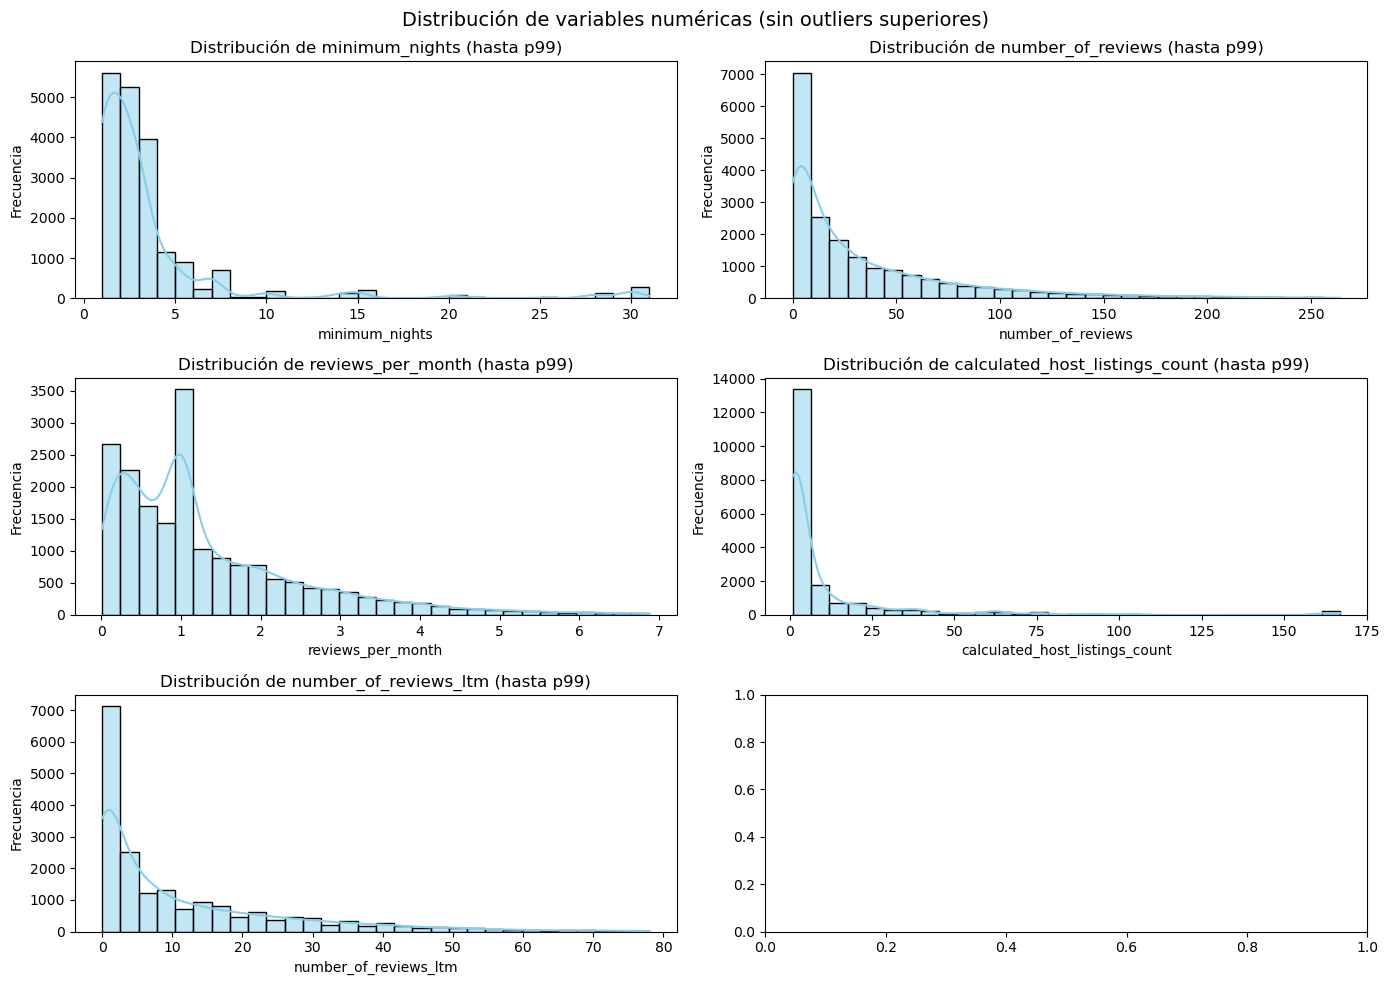

In [459]:
variables = ['minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'number_of_reviews_ltm']

# Tabla de percentiles
print("=== TABLA DE PERCENTILES ===\n")
for var in variables:
    print(f"--- {var} ---")
    print(X_train[var].describe(percentiles=[.25, .50, .75, .90, .95, .99]))
    print()

# Histogramas recortados por p99
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(variables):
    p99 = X_train[var].quantile(0.99)
    datos = X_train[X_train[var] <= p99][var].dropna()
    
    sns.histplot(datos, bins=30, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución de {var} (hasta p99)')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de variables numéricas (sin outliers superiores)', fontsize=14)
plt.tight_layout()
plt.show()

Analizamos todas las variables numericas y se observa que entre el percentil 99% y el 100% hay serie de valores que no son tipicos pero estan dentro de los valores razonables. Por ejemplo en la variable **minimum_nights** el percentil 99% es 31 dias (1 mes) y el maximo son 720 dias (2 anios) y en ese rango entre 31 y 760 hay varios valores. Otro caso la variable **reviews_per_month** el valor maximo es 27 que es menor que los dias maximo de cualquier mes.

In [460]:
X_train[X_train['minimum_nights']>100].count()

id                                56
name                              56
host_id                           56
host_profile_id                   56
host_name                         56
neighbourhood                     56
latitude                          56
longitude                         56
room_type                         56
minimum_nights                    56
number_of_reviews                 56
reviews_per_month                 56
calculated_host_listings_count    56
number_of_reviews_ltm             56
last_review_anio                  56
last_review_mes                   56
last_review_dia                   56
dtype: int64

In [461]:
X_train[X_train['number_of_reviews']>264].count()

id                                191
name                              191
host_id                           191
host_profile_id                   191
host_name                         191
neighbourhood                     191
latitude                          191
longitude                         191
room_type                         191
minimum_nights                    191
number_of_reviews                 191
reviews_per_month                 191
calculated_host_listings_count    191
number_of_reviews_ltm             191
last_review_anio                  191
last_review_mes                   191
last_review_dia                   191
dtype: int64

In [462]:
X_train[X_train['reviews_per_month']>20].count()

id                                1
name                              1
host_id                           1
host_profile_id                   1
host_name                         1
neighbourhood                     1
latitude                          1
longitude                         1
room_type                         1
minimum_nights                    1
number_of_reviews                 1
reviews_per_month                 1
calculated_host_listings_count    1
number_of_reviews_ltm             1
last_review_anio                  1
last_review_mes                   1
last_review_dia                   1
dtype: int64

In [463]:
X_train[X_train['calculated_host_listings_count']>167].count()


id                                135
name                              135
host_id                           135
host_profile_id                   135
host_name                         135
neighbourhood                     135
latitude                          135
longitude                         135
room_type                         135
minimum_nights                    135
number_of_reviews                 135
reviews_per_month                 135
calculated_host_listings_count    135
number_of_reviews_ltm             135
last_review_anio                  135
last_review_mes                   135
last_review_dia                   135
dtype: int64

In [464]:
X_train[X_train['number_of_reviews']>1000].count()


id                                1
name                              1
host_id                           1
host_profile_id                   1
host_name                         1
neighbourhood                     1
latitude                          1
longitude                         1
room_type                         1
minimum_nights                    1
number_of_reviews                 1
reviews_per_month                 1
calculated_host_listings_count    1
number_of_reviews_ltm             1
last_review_anio                  1
last_review_mes                   1
last_review_dia                   1
dtype: int64

### Asi es el comportamiento de todas las variables numerica por lo tanto no vamos a eliminar valores outliners

Ahora vamos a tratar la codificacion de las variables categoricas

In [465]:
X_train.describe(include='str')

,name,host_name,neighbourhood,room_type
count,19143,19143,19143,19143
unique,18256,3172,48,4
top,Departamento en Buenos Aires,Federico,Palermo,Entire home/apt
freq,43,321,6283,17430


La variable name, se deberia eliminar ya que varios usuarios comparte el mismo nombre (por ejemplo: Matias) pero son distintas personas y yo grafique la cantidad de propiedades por personas, esta variables las sumaba en un misma persona.

La variables host_name tambien deberia ser eliminada porque no aporta ningun valor. Ya que con el valor numerico de id se identifica la publicacion y la otra variable host_id identifica al  anfitrion

O sea que solo nos quedan por codificar **neighbourhood** y **room_type**

Para el caso de **neighbourhood**, vamos a importar un csv con las comunas de las cuales son parte cada barrio para asi agruparlos por comun y bajar la cardinalidad de 48 a 15

In [475]:
comunas = pd.read_csv(r'C:\Users\Gonzalo Rodriguez\OneDrive\Documentos\Especializacion en IA -CEIA\Analisis de datos\TP\barrios_comunas_caba.csv')

In [476]:
comunas.head()

,barrio,comuna
0,Palermo,14
1,Villa Devoto,11
2,Recoleta,2
3,Monserrat,1
4,San Nicolas,1


In [478]:
X_train = X_train.merge(comunas, left_on='neighbourhood', right_on='barrio', how='left')

In [479]:
X_train.head()

,id,name,host_id,host_profile_id,host_name,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,number_of_reviews_ltm,last_review_anio,last_review_mes,last_review_dia,barrio,comuna
0,12754901,SOLER APARTMENTS I,10832119,1462850666220897262,Ari Y Pablo,Palermo,-34.580640,-58.435410,Entire home/apt,2.0,311,2.62,18,36,2025.0,12.0,16.0,Palermo,14
1,1578601620230605997,Charcas Temporario,27425595,1462640967782255484,Angie,Palermo,-34.588204,-58.416657,Entire home/apt,2.0,0,1.00,1,0,0.0,0.0,0.0,Palermo,14
2,1256431177477838900,4 ambientes. 1 cama matrimonial y 2 de 1 plaza,16105482,1462978619078121283,Paula,Villa Devoto,-34.599277,-58.504396,Entire home/apt,4.0,14,1.00,1,11,2025.0,12.0,28.0,Villa Devoto,11
3,894965193342312176,Incredible Modern and Luxe DecoRecoleta D902,514858047,1470315892442651780,Deco,Recoleta,-34.587569,-58.392143,Entire home/apt,1.0,75,2.33,3,34,2026.0,1.0,13.0,Recoleta,2
4,1523509040053337513,Departament at Center of the City,479653812,1493003547320008174,Kiara,Monserrat,-34.616527,-58.383787,Private room,1.0,2,0.85,1,2,2025.0,11.0,25.0,Monserrat,1


Entonces dropeamos las columnas categoricas y nos quedamos con comuna que es la numerica

In [480]:
X_train = X_train.drop(columns=['neighbourhood', 'barrio']).copy()

Corroboramos que no haya queda ningun dato sin barrio

In [481]:
print(X_train['comuna'].isnull().sum())

0


Antes de hacer el OHE de barrio y room_type vamos a dropear las columnas que dijimos anteriormente

In [483]:
X_train.head(5)

,id,name,host_id,host_profile_id,host_name,latitude,longitude,room_type,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,number_of_reviews_ltm,last_review_anio,last_review_mes,last_review_dia,comuna
0,12754901,SOLER APARTMENTS I,10832119,1462850666220897262,Ari Y Pablo,-34.580640,-58.435410,Entire home/apt,2.0,311,2.62,18,36,2025.0,12.0,16.0,14
1,1578601620230605997,Charcas Temporario,27425595,1462640967782255484,Angie,-34.588204,-58.416657,Entire home/apt,2.0,0,1.00,1,0,0.0,0.0,0.0,14
2,1256431177477838900,4 ambientes. 1 cama matrimonial y 2 de 1 plaza,16105482,1462978619078121283,Paula,-34.599277,-58.504396,Entire home/apt,4.0,14,1.00,1,11,2025.0,12.0,28.0,11
3,894965193342312176,Incredible Modern and Luxe DecoRecoleta D902,514858047,1470315892442651780,Deco,-34.587569,-58.392143,Entire home/apt,1.0,75,2.33,3,34,2026.0,1.0,13.0,2
4,1523509040053337513,Departament at Center of the City,479653812,1493003547320008174,Kiara,-34.616527,-58.383787,Private room,1.0,2,0.85,1,2,2025.0,11.0,25.0,1


Dijimos que quedaba id y host_id y borramos name, host_profile_id, host_name

In [484]:
X_train = X_train.drop(columns=['name', 'host_profile_id','host_name']).copy()

In [485]:
X_train.shape

(19143, 14)

Ahora vamos a codifiar con One Hote Encoding a las bariables type_room que es categorica y tambien lo vamo a hacer con barrio que a pesar de haber quedado de forma numerica no nos sirve porque los barrios no tienen orden (deo 1 ao 15) como estan ahora, por eso vamos a aplicar OHE

In [486]:
from sklearn.preprocessing import OneHotEncoder

# Definir columnas a codificar
columnas_ohe = ['comuna', 'room_type']

# Instanciar el encoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')

# Fit y transform en X_train
ohe_train = ohe.fit_transform(X_train[columnas_ohe])

# Crear dataframe con las nuevas columnas
ohe_cols = ohe.get_feature_names_out(columnas_ohe)
ohe_train_df = pd.DataFrame(ohe_train, columns=ohe_cols, index=X_train.index)

# Eliminar columnas originales y agregar las codificadas
X_train = X_train.drop(columns=columnas_ohe)
X_train = pd.concat([X_train, ohe_train_df], axis=1)


In [487]:
print(X_train.shape)
print(X_train.columns.tolist())

(19143, 29)
['id', 'host_id', 'latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'number_of_reviews_ltm', 'last_review_anio', 'last_review_mes', 'last_review_dia', 'comuna_2', 'comuna_3', 'comuna_4', 'comuna_5', 'comuna_6', 'comuna_7', 'comuna_8', 'comuna_9', 'comuna_10', 'comuna_11', 'comuna_12', 'comuna_13', 'comuna_14', 'comuna_15', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room']
